# ERA5 Relative Humidity 850 hPa

**Nguồn:** ERA5 Pressure-Level Reanalysis (CDS API)  
**Variable:** `relative_humidity` tại level 850 hPa  
**Mục đích:** RH cao + BLH thấp = điều kiện ô nhiễm nặng (hạt PM2.5 hút ẩm, tăng kích thước)  
**Output:** `data/processed/era5_rh850_daily.csv` → merge vào `daily_merged.csv`

**Features tạo ra:**
- `rh850_mean` — RH trung bình ngày tại 850 hPa (%)
- `rh850_max` — RH max trong ngày
- `rh850_morning` — RH trung bình 06–09h (giờ Việt Nam)

## Cell 1 — Cài đặt

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cdsapi", "xarray", "netCDF4"])
print("Ready.")

Ready.


## Cell 2 — Cấu hình

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import cdsapi, xarray as xr

ROOT    = Path("D:/Bussiness_plan/Multimodal_PM25")
RAW_DIR = ROOT / "data/raw/era5_rh850"; RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR = ROOT / "data/processed";    PROC_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV  = PROC_DIR / "era5_rh850_daily.csv"
MERGED   = PROC_DIR / "daily_merged.csv"

CDS_URL = "https://cds.climate.copernicus.eu/api"
CDS_KEY = "e07e7cb2-ac0a-4459-92c0-c97f21e9af35"

STATIONS = {
    2161292: (21.0152, 105.7999),
    2161306: (21.0500, 105.7400),
    4946811: (21.0491, 105.8831),
    4946812: (21.0031, 105.7947),
    4946813: (21.0052, 105.8418),
    6123215: (20.9933, 105.9441),
}

# Bounding box bao phủ Hà Nội (N, W, S, E)
LAT_N, LON_W, LAT_S, LON_E = 21.2, 105.6, 20.8, 106.1

PRESSURE_LEVEL = "850"
HOURS = [f"{h:02d}:00" for h in range(24)]

# Download từng tháng để tránh "request too large"
MONTHS_TO_DOWNLOAD = (
    [(2024, m) for m in range(1, 13)] +
    [(2025, m) for m in range(1, 13)] +
    [(2026, m) for m in range(1, 6)]
)

print(f"Stations : {len(STATIONS)}")
print(f"Level    : {PRESSURE_LEVEL} hPa")
print(f"Months   : {len(MONTHS_TO_DOWNLOAD)} chunks (2024-01 → 2026-05)")
print(f"Raw dir  : {RAW_DIR}")

Stations : 6
Level    : 850 hPa
Months   : 29 chunks (2024-01 → 2026-05)
Raw dir  : D:\Bussiness_plan\Multimodal_PM25\data\raw\era5_rh850


## Cell 3 — Download từng tháng (skip nếu đã có)

In [3]:
import calendar

c = cdsapi.Client(url=CDS_URL, key=CDS_KEY)

for (yr, mo) in MONTHS_TO_DOWNLOAD:
    tag  = f"{yr}_{mo:02d}"
    part = RAW_DIR / f"era5_rh850_{tag}.nc"

    if part.exists():
        print(f"  {tag}: skip (exists)")
        continue

    n_days = calendar.monthrange(yr, mo)[1]
    days   = [f"{d:02d}" for d in range(1, n_days + 1)]

    print(f"  {tag}: downloading ({n_days} days × 24h × 1 level) ...", end=" ", flush=True)
    try:
        c.retrieve(
            "reanalysis-era5-pressure-levels",
            {
                "product_type": "reanalysis",
                "variable":      "relative_humidity",
                "pressure_level": PRESSURE_LEVEL,
                "year":  str(yr),
                "month": f"{mo:02d}",
                "day":   days,
                "time":  HOURS,
                "area":  [LAT_N, LON_W, LAT_S, LON_E],
                "format": "netcdf",
            },
            str(part),
        )
        print(f"OK  ({part.stat().st_size/1024:.0f} KB)")
    except Exception as e:
        print(f"ERROR: {e}")

files = sorted(RAW_DIR.glob("era5_rh850_????_??.nc"))
print(f"\nTotal files: {len(files)} / {len(MONTHS_TO_DOWNLOAD)}")

  2024_01: downloading (31 days × 24h × 1 level) ... 

2026-05-21 00:43:58,738 INFO Request ID is 2eb8d616-e99e-4d72-8b33-3eca8af01954
2026-05-21 00:43:58,972 INFO status has been updated to accepted
2026-05-21 00:44:08,095 INFO status has been updated to running
2026-05-21 00:45:16,412 INFO status has been updated to successful
                                                                                         

OK  (82 KB)
  2024_02: downloading (29 days × 24h × 1 level) ... 

2026-05-21 00:45:20,000 INFO Request ID is d7987a29-85c9-4af5-8aea-98be85d7ffb1
2026-05-21 00:45:20,511 INFO status has been updated to accepted
2026-05-21 00:45:31,052 INFO status has been updated to running
2026-05-21 00:46:39,455 INFO status has been updated to successful
                                                                                         

OK  (80 KB)
  2024_03: downloading (31 days × 24h × 1 level) ... 

...

OK  (82 KB)
  2026_04: downloading (30 days × 24h × 1 level) ... 

2026-05-21 01:28:31,498 INFO Request ID is 0338a05b-d8b0-495c-a80d-425e32079f8d
2026-05-21 01:28:31,736 INFO status has been updated to accepted
2026-05-21 01:28:46,347 INFO status has been updated to running
2026-05-21 01:29:49,114 INFO status has been updated to successful
                                                                                         

OK  (81 KB)
  2026_05: downloading (31 days × 24h × 1 level) ... 

2026-05-21 01:29:53,616 INFO Request ID is 423e7530-00e2-47ba-bdfc-b33f3de770a1
2026-05-21 01:29:53,928 INFO status has been updated to accepted
2026-05-21 01:30:20,754 INFO status has been updated to running
2026-05-21 01:30:37,033 INFO status has been updated to successful
                                                                                         

OK  (54 KB)

Total files: 29 / 29


## Cell 4 — Kiểm tra file NC

In [4]:
files = sorted(RAW_DIR.glob("era5_rh850_????_??.nc"))
print(f"Files found: {len(files)}")

if files:
    ds = xr.open_dataset(files[0])
    print("\nSample file:", files[0].name)
    print("Variables :", list(ds.data_vars))
    print("Coords    :", list(ds.coords))
    print("Dims      :", dict(ds.dims))
    print(ds)

Files found: 29

Sample file: era5_rh850_2024_01.nc
Variables : ['r']
Coords    : ['number', 'valid_time', 'pressure_level', 'latitude', 'longitude', 'expver']
Dims      : {'valid_time': 744, 'pressure_level': 1, 'latitude': 1, 'longitude': 2}
<xarray.Dataset> Size: 24kB
Dimensions:         (valid_time: 744, pressure_level: 1, latitude: 1,
                     longitude: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31...
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 8B 21.0
  * longitude       (longitude) float64 16B 105.8 106.0
    number          int64 8B ...
    expver          (valid_time) <U4 12kB ...
Data variables:
    r               (valid_time, pressure_level, latitude, longitude) float32 6kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22096\782969277.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dims      :", dict(ds.dims))


## Cell 5 — Trích xuất daily RH850 cho từng trạm

In [5]:
def process_rh850_file(nc_path):
    """Đọc 1 file NC, trả về DataFrame hourly với cột: time, lat, lon, rh850."""
    ds  = xr.open_dataset(nc_path)
    var = "r"  # ERA5 pressure-level relative humidity = 'r'
    if var not in ds.data_vars:
        # fallback: lấy var đầu tiên
        var = list(ds.data_vars)[0]

    da = ds[var]

    # Xử lý dimension thừa của CDS API v3
    if "expver" in da.dims: da = da.isel(expver=0)
    if "number" in da.dims: da = da.isel(number=0)
    if "pressure_level" in da.dims: da = da.isel(pressure_level=0)
    if "level" in da.dims:          da = da.isel(level=0)

    tc   = "valid_time" if "valid_time" in ds.coords else "time"
    lats = da.latitude.values
    lons = da.longitude.values
    times = pd.to_datetime(da[tc].values)

    records = []
    for it, t in enumerate(times):
        for ilat, lat in enumerate(lats):
            for ilon, lon in enumerate(lons):
                val = float(da.values[it, ilat, ilon])
                records.append({"time": t, "latitude": lat, "longitude": lon, "rh850": val})
    return pd.DataFrame(records)


def nearest_grid(df_hourly, lat, lon):
    """Lấy grid point gần nhất với trạm."""
    lats = df_hourly["latitude"].unique()
    lons = df_hourly["longitude"].unique()
    best_lat = lats[np.argmin(np.abs(lats - lat))]
    best_lon = lons[np.argmin(np.abs(lons - lon))]
    return df_hourly[(df_hourly["latitude"] == best_lat) &
                     (df_hourly["longitude"] == best_lon)].copy()


files = sorted(RAW_DIR.glob("era5_rh850_????_??.nc"))
print(f"Processing {len(files)} files ...")

all_station_dfs = {loc_id: [] for loc_id in STATIONS}

for nc_path in files:
    print(f"  {nc_path.name} ...", end=" ", flush=True)
    df_hr = process_rh850_file(nc_path)

    for loc_id, (lat, lon) in STATIONS.items():
        df_st = nearest_grid(df_hr, lat, lon)
        df_st = df_st[["time", "rh850"]].copy()
        df_st.insert(0, "location_id", loc_id)
        all_station_dfs[loc_id].append(df_st)

    print("OK")

# Ghép và tính daily stats
daily_records = []
for loc_id, chunks in all_station_dfs.items():
    df_st = pd.concat(chunks, ignore_index=True).drop_duplicates("time")
    df_st["time"]       = pd.to_datetime(df_st["time"])
    df_st["date"]       = df_st["time"].dt.normalize()
    df_st["is_morning"] = df_st["time"].dt.hour.isin([6, 7, 8, 9])

    daily = (df_st.groupby("date")["rh850"]
             .agg(rh850_mean="mean", rh850_max="max")
             .reset_index())
    morn  = (df_st[df_st["is_morning"]]
             .groupby("date")["rh850"].mean()
             .rename("rh850_morning").reset_index())
    daily = daily.merge(morn, on="date", how="left")
    daily.insert(0, "location_id", loc_id)
    daily_records.append(daily)

rh_df = (pd.concat(daily_records, ignore_index=True)
         .sort_values(["location_id", "date"])
         .reset_index(drop=True))

print(f"\nTotal rows : {len(rh_df)}")
print(f"Date range : {rh_df['date'].min()} -> {rh_df['date'].max()}")
print(f"Coverage   : {rh_df['rh850_mean'].notna().mean()*100:.1f}%")
print(rh_df[["rh850_mean","rh850_max","rh850_morning"]].describe().round(1))

Processing 29 files ...
  era5_rh850_2024_01.nc ... OK
  era5_rh850_2024_02.nc ... OK
  era5_rh850_2024_03.nc ... OK
  era5_rh850_2024_04.nc ... OK
  era5_rh850_2024_05.nc ... OK
  era5_rh850_2024_06.nc ... OK
  era5_rh850_2024_07.nc ... OK
  era5_rh850_2024_08.nc ... OK
  era5_rh850_2024_09.nc ... OK
  era5_rh850_2024_10.nc ... OK
  era5_rh850_2024_11.nc ... OK
  era5_rh850_2024_12.nc ... OK
  era5_rh850_2025_01.nc ... OK
  era5_rh850_2025_02.nc ... OK
  era5_rh850_2025_03.nc ... OK
  era5_rh850_2025_04.nc ... OK
  era5_rh850_2025_05.nc ... OK
  era5_rh850_2025_06.nc ... OK
  era5_rh850_2025_07.nc ... OK
  era5_rh850_2025_08.nc ... OK
  era5_rh850_2025_09.nc ... OK
  era5_rh850_2025_10.nc ... OK
  era5_rh850_2025_11.nc ... OK
  era5_rh850_2025_12.nc ... OK
  era5_rh850_2026_01.nc ... OK
  era5_rh850_2026_02.nc ... OK
  era5_rh850_2026_03.nc ... OK
  era5_rh850_2026_04.nc ... OK
  era5_rh850_2026_05.nc ... OK

Total rows : 5196
Date range : 2024-01-01 00:00:00 -> 2026-05-15 00:00:00
Co

## Cell 6 — Visualize

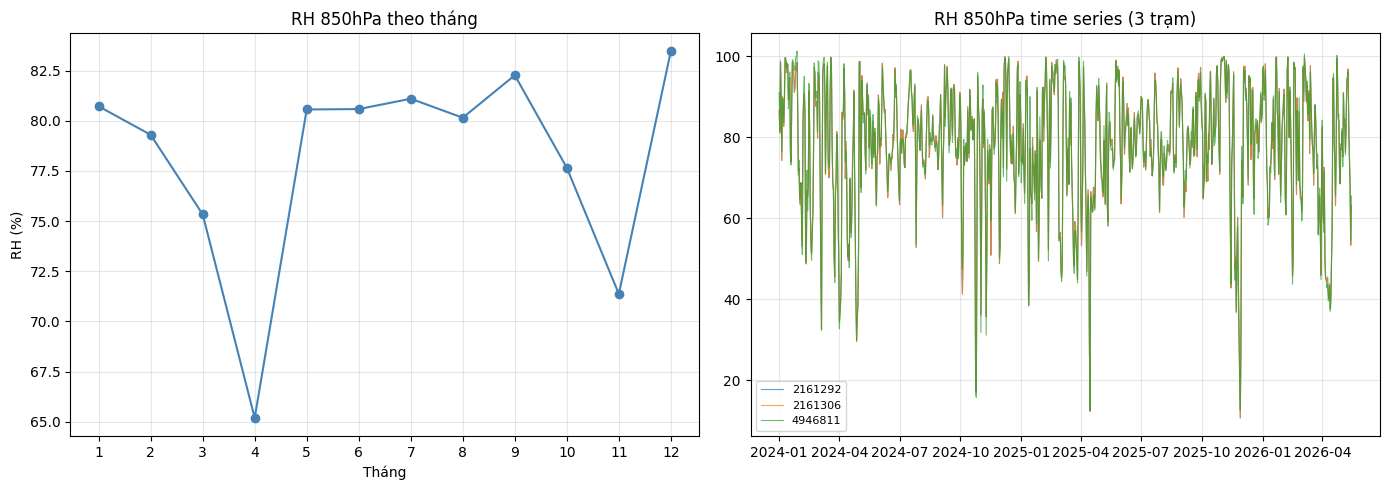

Saved: outputs/era5_rh850_seasonal.png


In [6]:
import matplotlib.pyplot as plt

rh_df["month"] = pd.to_datetime(rh_df["date"]).dt.month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = rh_df.groupby("month")["rh850_mean"].mean()
monthly.plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set_title("RH 850hPa theo tháng", fontsize=12)
axes[0].set_xlabel("Tháng"); axes[0].set_ylabel("RH (%)")
axes[0].set_xticks(range(1, 13)); axes[0].grid(alpha=0.3)

for loc_id in list(STATIONS.keys())[:3]:
    sub = rh_df[rh_df["location_id"] == loc_id]
    axes[1].plot(pd.to_datetime(sub["date"]), sub["rh850_mean"],
                 alpha=0.7, linewidth=0.8, label=str(loc_id))
axes[1].set_title("RH 850hPa time series (3 trạm)", fontsize=12)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / "outputs/era5_rh850_seasonal.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/era5_rh850_seasonal.png")

## Cell 7 — Correlation RH850 vs PM2.5

Pearson r (RH 850hPa vs PM2.5): -0.199  (n=2274)


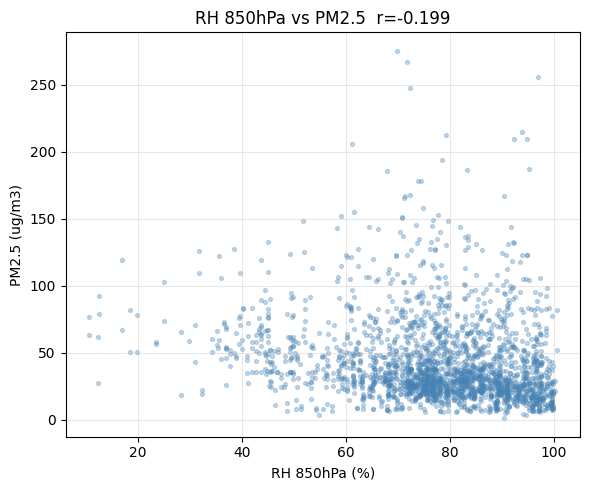

In [7]:
import matplotlib.pyplot as plt

main = pd.read_csv(MERGED, parse_dates=["date"])
rh_df["date"] = pd.to_datetime(rh_df["date"])

check = main.merge(rh_df[["location_id","date","rh850_mean"]], on=["location_id","date"], how="left")
valid = check[["pm25","rh850_mean"]].dropna()
r = valid.corr().iloc[0, 1]
print(f"Pearson r (RH 850hPa vs PM2.5): {r:.3f}  (n={len(valid)})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid["rh850_mean"], valid["pm25"], alpha=0.3, s=8, color="steelblue")
ax.set_xlabel("RH 850hPa (%)"); ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title(f"RH 850hPa vs PM2.5  r={r:.3f}", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "outputs/era5_rh850_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

## Cell 8 — Lưu CSV + Merge vào daily_merged.csv

In [8]:
rh_df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}  shape={rh_df.shape}")

main = pd.read_csv(MERGED, parse_dates=["date"])
for col in ["rh850_mean", "rh850_max", "rh850_morning"]:
    if col in main.columns:
        main.drop(columns=[col], inplace=True)

rh_df["date"] = pd.to_datetime(rh_df["date"])
main = main.merge(
    rh_df[["location_id","date","rh850_mean","rh850_max","rh850_morning"]],
    on=["location_id","date"], how="left"
)

for col in ["rh850_mean", "rh850_max", "rh850_morning"]:
    pct = main[col].notna().mean() * 100
    print(f"  {col}: {pct:.1f}% coverage")

main.to_csv(MERGED, index=False)
print(f"\nUpdated: {MERGED}  shape={main.shape}")

Saved: D:\Bussiness_plan\Multimodal_PM25\data\processed\era5_rh850_daily.csv  shape=(5196, 6)
  rh850_mean: 100.0% coverage
  rh850_max: 100.0% coverage
  rh850_morning: 100.0% coverage

Updated: D:\Bussiness_plan\Multimodal_PM25\data\processed\daily_merged.csv  shape=(2274, 78)


## Cell 9 — Thêm vào train_3d_v2.py

```python
# ctx_feats
+ ["rh850_mean", "rh850_morning"]

# tab_cols
+ ["rh850_mean", "rh850_max", "rh850_morning"]
```

Xóa cache trước khi chạy lại:
```python
import shutil, glob, os
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
for f in glob.glob('outputs/final_3d_v2/neural_seed*.pt'): os.remove(f)
```

In [9]:
import shutil, glob, os
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
for f in glob.glob('outputs/final_3d_v2/neural_seed*.pt'): os.remove(f)
